In [16]:
from google.colab import files

uploaded = files.upload()

Saving dataset_02_loan_approval_screening.csv to dataset_02_loan_approval_screening (1).csv


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
df = pd.read_csv("dataset_02_loan_approval_screening.csv")
print(df.shape)
df.head()


(1000, 7)


,income_monthly,credit_score,debt_to_income,employment_years,loan_amount,prior_defaults,target
0,183.46,826.0,91.27,12.31,316.64,5,0
1,210.10,664.0,93.23,6.05,122.07,2,1
2,58.07,594.0,277.85,1.05,170.48,4,0
3,165.98,724.0,97.53,0.00,146.82,2,1
4,77.82,600.0,39.69,8.24,213.94,3,0


In [18]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nClass balance:\n", df["target"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   income_monthly    1000 non-null   float64
 1   credit_score      1000 non-null   float64
 2   debt_to_income    1000 non-null   float64
 3   employment_years  1000 non-null   float64
 4   loan_amount       1000 non-null   float64
 5   prior_defaults    1000 non-null   int64  
 6   target            1000 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 54.8 KB
None

Missing values:
 income_monthly      0
credit_score        0
debt_to_income      0
employment_years    0
loan_amount         0
prior_defaults      0
target              0
dtype: int64

Duplicates: 0

Class balance:
 target
0    500
1    500
Name: count, dtype: int64


In [19]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [20]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000))])

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.705
Precision: 0.6880733944954128
Recall   : 0.75
F1 Score : 0.7177033492822966
ROC-AUC  : 0.7823


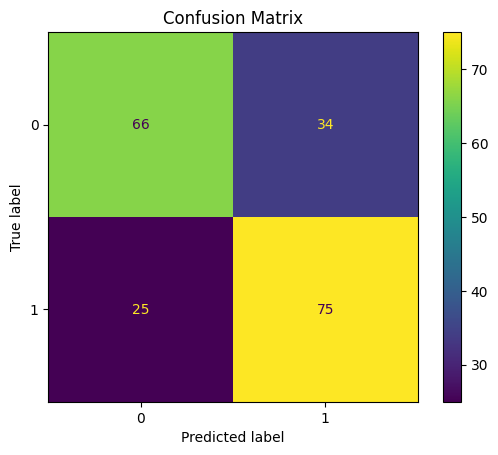

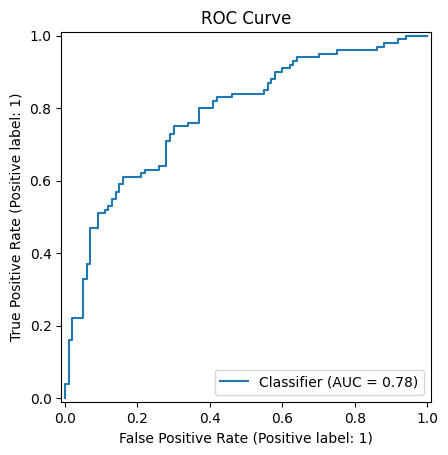

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

In [23]:
lr = model.named_steps["lr"]

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

print(coef.sort_values("Coefficient", ascending=False))

            Feature  Coefficient
4       loan_amount     0.594229
0    income_monthly     0.585141
2    debt_to_income     0.434223
5    prior_defaults    -0.515878
1      credit_score    -0.524847
3  employment_years    -0.608752
